# SyriaTel Customer Churn Analysis
## Phase 3 Project — Binary Classification

**Author:** Joel Muoki Andrew   
**Date:** April 2026  
**Dataset:** [SyriaTel Churn Dataset (Kaggle)](https://www.kaggle.com/becksddf/churn-in-telecoms-dataset)

---

## Project Overview

This notebook documents a full end-to-end data science workflow for predicting customer churn at **SyriaTel**, a telecommunications company. Customer churn refers to the phenomenon where customers stop using a company's services. Identifying customers likely to churn before they do allow businesses to take proactive retention action, saving significant revenue.

**Business Problem:**  
SyriaTel's management wants to understand: *Are there predictable patterns in customer behavior that indicate a customer is about to leave?* If we can flag at-risk customers early, the retention team can intervene with targeted offers or improved service.

**Stakeholder:** SyriaTel Business / Customer Retention Team

**Why Machine Learning?**  
Simple rule-based methods (like flagging customers who call support more than five times) fail to capture complex relationships between multiple factors. On the other hand, a machine learning classifier can analyze many features at once, uncover subtle patterns, and assign each customer a probability of churning—something fixed rules and thresholds can’t achieve.

---

## Table of Contents
1. [Business & Data Understanding](#1)
2. [Data Preparation](#2)
3. [Exploratory Data Analysis (EDA)](#3)
4. [Modeling — Baseline Logistic Regression](#4)
5. [Modeling — Decision Tree](#5)
6. [Modeling — Tuned Decision Tree](#6)
7. [Modeling — Random Forest (Ensemble)](#7)
8. [Final Model Evaluation](#8)
9. [Conclusions & Recommendations](#9)

---
## 1. Business & Data Understanding <a id='1'></a>

### 1.1 The Business Problem

Acquiring a new customer is significantly more expensive—often several times costlier—than retaining an existing one. For SyriaTel, every churned customer represents lost recurring revenue and a high replacement cost. The goal is to build a **binary classifier** that predicts:

- `True` → customer will churn (positive class)
- `False` → customer will stay (negative class)

### 1.2 Metric Choice — Why Recall?

In churn prediction, the business cost of a **False Negative** (missing a churner) is typically much higher than a **False Positive** (incorrectly flagging a loyal customer for intervention). Offering a retention deal to a loyal customer has a low cost; failing to reach an about-to-leave customer means losing them entirely.

Therefore, we will prioritize **Recall** (sensitivity) as our primary metric while also monitoring **F1-Score** for balance, and **ROC-AUC** for overall discrimination ability.

### 1.3 Dataset Description

The dataset contains **3,333 records** and **21 columns**. Each row represents one customer. Key feature categories:

| Category | Features |
|---|---|
| Account Info | `state`, `account length`, `area code`, `phone number` |
| Plan Info | `international plan`, `voice mail plan`, `number vmail messages` |
| Usage — Day | `total day minutes`, `total day calls`, `total day charge` |
| Usage — Evening | `total eve minutes`, `total eve calls`, `total eve charge` |
| Usage — Night | `total night minutes`, `total night calls`, `total night charge` |
| Usage — International | `total intl minutes`, `total intl calls`, `total intl charge` |
| Support | `customer service calls` |
| Target | `churn` (True/False) |

In [2]:
# ============================================================
# SECTION 1 — IMPORTS & DATA LOADING
# ============================================================

# Core data libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn — preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder

# Scikit-learn — models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# Scikit-learn — metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    recall_score,
    f1_score
)

# Display settings
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

import warnings
warnings.filterwarnings('ignore')

print(" All libraries imported successfully.")

 All libraries imported successfully.


In [3]:
# Load the dataset
df = pd.read_csv('bigml_59c28831336c6604c800002a.csv')

print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
df.head()

Dataset shape: (3333, 21)
Rows: 3,333 | Columns: 21


,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1000,110,45.0700,197.4000,99,16.7800,244.7000,91,11.0100,10.0000,3,2.7000,1,False
1,OH,107,415,371-7191,no,yes,26,161.6000,123,27.4700,195.5000,103,16.6200,254.4000,103,11.4500,13.7000,3,3.7000,1,False
2,NJ,137,415,358-1921,no,no,0,243.4000,114,41.3800,121.2000,110,10.3000,162.6000,104,7.3200,12.2000,5,3.2900,0,False
3,OH,84,408,375-9999,yes,no,0,299.4000,71,50.9000,61.9000,88,5.2600,196.9000,89,8.8600,6.6000,7,1.7800,2,False
4,OK,75,415,330-6626,yes,no,0,166.7000,113,28.3400,148.3000,122,12.6100,186.9000,121,8.4100,10.1000,3,2.7300,3,False


In [4]:
# Checking column names
df.columns

Index(['state', 'account length', 'area code', 'phone number',
       'international plan', 'voice mail plan', 'number vmail messages',
       'total day minutes', 'total day calls', 'total day charge',
       'total eve minutes', 'total eve calls', 'total eve charge',
       'total night minutes', 'total night calls', 'total night charge',
       'total intl minutes', 'total intl calls', 'total intl charge',
       'customer service calls', 'churn'],
      dtype='object')

In [6]:
# Quick overview of data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

In [7]:
# Summary statistics for numeric columns
df.describe()

,account length,area code,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
count,3333.0000,3333.0000,3333.0000,3333.0000,3333.0000,3333.0000,3333.0000,3333.0000,3333.0000,3333.0000,3333.0000,3333.0000,3333.0000,3333.0000,3333.0000,3333.0000
mean,101.0648,437.1824,8.0990,179.7751,100.4356,30.5623,200.9803,100.1143,17.0835,200.8720,100.1077,9.0393,10.2373,4.4794,2.7646,1.5629
std,39.8221,42.3713,13.6884,54.4674,20.0691,9.2594,50.7138,19.9226,4.3107,50.5738,19.5686,2.2759,2.7918,2.4612,0.7538,1.3155
min,1.0000,408.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,23.2000,33.0000,1.0400,0.0000,0.0000,0.0000,0.0000
25%,74.0000,408.0000,0.0000,143.7000,87.0000,24.4300,166.6000,87.0000,14.1600,167.0000,87.0000,7.5200,8.5000,3.0000,2.3000,1.0000
50%,101.0000,415.0000,0.0000,179.4000,101.0000,30.5000,201.4000,100.0000,17.1200,201.2000,100.0000,9.0500,10.3000,4.0000,2.7800,1.0000
75%,127.0000,510.0000,20.0000,216.4000,114.0000,36.7900,235.3000,114.0000,20.0000,235.3000,113.0000,10.5900,12.1000,6.0000,3.2700,2.0000
max,243.0000,510.0000,51.0000,350.8000,165.0000,59.6400,363.7000,170.0000,30.9100,395.0000,175.0000,17.7700,20.0000,20.0000,5.4000,9.0000


In [8]:
# Check for missing values a critical first step
missing = df.isnull().sum()
missing

state                     0
account length            0
area code                 0
phone number              0
international plan        0
voice mail plan           0
number vmail messages     0
total day minutes         0
total day calls           0
total day charge          0
total eve minutes         0
total eve calls           0
total eve charge          0
total night minutes       0
total night calls         0
total night charge        0
total intl minutes        0
total intl calls          0
total intl charge         0
customer service calls    0
churn                     0
dtype: int64

In [9]:
# Check duplicates
df.duplicated().sum()

0

**Observation:** The dataset is clean no missing values or duplicates across all 3,333 rows and 21 columns. This is great and means we can proceed to preprocessing without imputation.

### 1.4 Target Variable — Class Balance Check

Before anything else, we must inspect how balanced the target classes are. Class imbalance can mislead models into simply predicting the majority class.

In [10]:
# Churn distribution
churn_counts = df['churn'].value_counts()
churn_pct = df['churn'].value_counts(normalize=True) * 100

print("Churn Value Counts:")
print(churn_counts)
print("\nChurn Percentages:")
print(churn_pct.round(2))

Churn Value Counts:
churn
False    2850
True      483
Name: count, dtype: int64

Churn Percentages:
churn
False   85.5100
True    14.4900
Name: proportion, dtype: float64


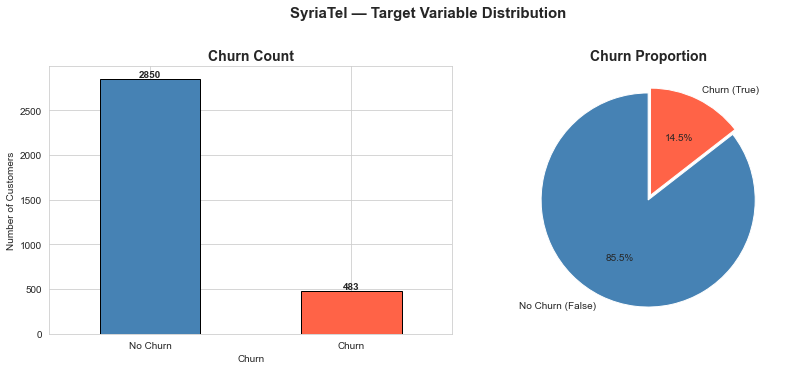

In [11]:
# Plot the target variable distribution
# Create a figure with 1 row and 2 subplots (side-by-side)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot churn counts as a bar chart
churn_counts.plot(
    kind='bar', 
    ax=axes[0], 
    color=['steelblue', 'tomato'],   # Colors for No Churn and Churn
    edgecolor='black'                # Outline color of bars
)
# Set title and axis labels for the bar chart
axes[0].set_title('Churn Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Number of Customers')

# Customize x-axis tick labels
axes[0].set_xticklabels(['No Churn', 'Churn'], rotation=0)

# Add value labels on top of each bar
for i, v in enumerate(churn_counts):
    axes[0].text(
        i, v + 20,           # Position slightly above each bar
        str(v),              # Display the count value
        ha='center',         # Horizontal alignment
        fontweight='bold'
    )

# Plot churn distribution as a pie chart
axes[1].pie(
    churn_counts,
    labels=['No Churn (False)', 'Churn (True)'],  # Labels for slices
    autopct='%1.1f%%',                           # Show percentage with 1 decimal place
    colors=['steelblue', 'tomato'],              # Matching colors with bar chart
    startangle=90,                               # Start angle for better orientation
    explode=(0, 0.05)                            # Slightly "explode" the Churn slice
)
# Set title for the pie chart
axes[1].set_title('Churn Proportion', fontsize=14, fontweight='bold')
# Add an overall title for the entire figure
plt.suptitle(
    'SyriaTel — Target Variable Distribution', 
    fontsize=15, 
    fontweight='bold', 
    y=1.02
)
# Adjust layout to prevent overlapping elements
plt.tight_layout()
plt.show()

**Key Insight:** The dataset is **imbalanced** — only ~14.5% of customers have churned. This means:
- A simple model that predicts “No Churn” for every customer might achieve about 85% accuracy, but it would fail to identify actual churners and therefore provide little practical value.
- We must use `class_weight='balanced'` in our models and prioritize **Recall** over raw Accuracy.

---
## 2. Data Preparation <a id='2'></a>

### 2.1 Feature Engineering & Encoding

Steps we will take:
1. **Drop irrelevant columns** — `phone number` is a unique identifier with no predictive value.
2. **Encode binary categorical columns** — `international plan` and `voice mail plan` are yes/no.
3. **Encode `state`** — We'll use Label Encoding (or drop it as it has too many categories to be directly useful without more sophisticated encoding).
4. **Convert target** to integer (0/1).
5. **Train-Test Split** — 80/20, stratified to preserve class ratio.
6. **Scale numeric features** — Required for Logistic Regression (distance-based).

In [12]:
# =========================================================================
# SECTION 2 — DATA PREPARATION
# ========================================================================== 

# Work on a copy to preserve original
data = df.copy()

# Step 1: Drop 'phone number' unique identifier, no predictive value
data.drop(columns=['phone number'], inplace=True)
print("Step 1 Dropped 'phone number'")

# Step 2: Encode binary yes/no columns
binary_cols = ['international plan', 'voice mail plan']
for col in binary_cols:
    data[col] = data[col].map({'yes': 1, 'no': 0})
print(f"Step 2 Encoded binary columns: {binary_cols}")

# Step 3: Encode 'state' with Label Encoding  # Used Label encoder over One hot encoding to avoid high dimensionality(too many columns)
le = LabelEncoder()
data['state'] = le.fit_transform(data['state'])
print("Step 3 Label-encoded 'state'")

# Step 4: Convert target column to integer
data['churn'] = data['churn'].astype(int)
print("Step 4 Converted 'churn' to integer (0/1)")

# Review the cleaned data
print(f"\nFinal shape: {data.shape}")
data.head()

Step 1 Dropped 'phone number'
Step 2 Encoded binary columns: ['international plan', 'voice mail plan']
Step 3 Label-encoded 'state'
Step 4 Converted 'churn' to integer (0/1)

Final shape: (3333, 20)


,state,account length,area code,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,16,128,415,0,1,25,265.1000,110,45.0700,197.4000,99,16.7800,244.7000,91,11.0100,10.0000,3,2.7000,1,0
1,35,107,415,0,1,26,161.6000,123,27.4700,195.5000,103,16.6200,254.4000,103,11.4500,13.7000,3,3.7000,1,0
2,31,137,415,0,0,0,243.4000,114,41.3800,121.2000,110,10.3000,162.6000,104,7.3200,12.2000,5,3.2900,0,0
3,35,84,408,1,0,0,299.4000,71,50.9000,61.9000,88,5.2600,196.9000,89,8.8600,6.6000,7,1.7800,2,0
4,36,75,415,1,0,0,166.7000,113,28.3400,148.3000,122,12.6100,186.9000,121,8.4100,10.1000,3,2.7300,3,0


In [13]:
# ============================================================
# Step 5: Train-Test Split (80/20, stratified)
# ============================================================

# Separate features (X) and target (y)
X = data.drop(columns=['churn'])
y = data['churn']

# Split into Training and Test set
# Stratified split ensures both sets have ~14.5% churn rate
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y       # <-- keeps class proportions
)

print(f"Training set: {X_train.shape[0]:,} rows")
print(f"Test set:     {X_test.shape[0]:,} rows")
print(f"\nTrain churn rate: {y_train.mean():.2%}")
print(f"Test churn rate:  {y_test.mean():.2%}")
print("\nStratification confirmed — both sets have similar churn proportions.")

Training set: 2,666 rows
Test set:     667 rows

Train churn rate: 14.48%
Test churn rate:  14.54%

Stratification confirmed — both sets have similar churn proportions.


In [14]:
# ============================================================
# Step 6: Scale Features (required for Logistic Regression)
# ============================================================

# IMPORTANT: Fit scaler ONLY on training data to prevent data leakage.
# Then use that fitted scaler to transform BOTH train and test.

scaler = StandardScaler()

# Fit on training data ONLY  # Fit-(learn) # Transorm- (Apply)
X_train_scaled = scaler.fit_transform(X_train) 

# Transform test data using the same fitted scaler
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns)

print(" Feature scaling complete.")
print("   Scaler fitted on training data only — no data leakage.")
print(f"   Training set mean (should be ~0): {X_train_scaled.mean().mean():.6f}")
print(f"   Training set std  (should be ~1): {X_train_scaled.std().mean():.6f}")

 Feature scaling complete.
   Scaler fitted on training data only — no data leakage.
   Training set mean (should be ~0): 0.000000
   Training set std  (should be ~1): 1.000188


---
## 3. Exploratory Data Analysis (EDA) <a id='3'></a>

Before modeling, we explore relationships between features and churn. Good EDA helps us understand which features are likely to be strong predictors and informs feature selection.

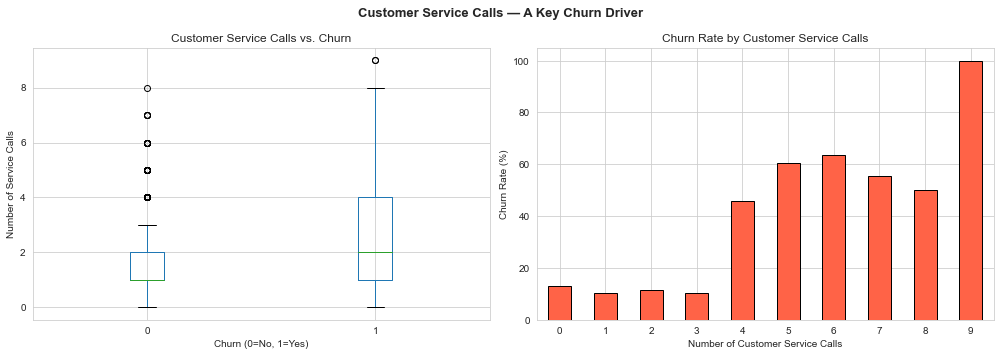

Churn rate by service call count:
customer service calls
0    13.2000
1    10.3000
2    11.5000
3    10.3000
4    45.8000
5    60.6000
6    63.6000
7    55.6000
8    50.0000
9   100.0000
Name: churn, dtype: float64


In [15]:
# ============================================================
# EDA 1: Churn vs. Customer Service Calls
# ============================================================
# We hypothesize that frustrated customers (many service calls) churn more.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
data.boxplot(column='customer service calls', by='churn', ax=axes[0])
axes[0].set_title('Customer Service Calls vs. Churn')
axes[0].set_xlabel('Churn (0=No, 1=Yes)')
axes[0].set_ylabel('Number of Service Calls')

# Bar chart: churn rate by number of service calls
churn_by_calls = data.groupby('customer service calls')['churn'].mean() * 100
churn_by_calls.plot(kind='bar', ax=axes[1], color='tomato', edgecolor='black')
axes[1].set_title('Churn Rate by Customer Service Calls')
axes[1].set_xlabel('Number of Customer Service Calls')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Customer Service Calls — A Key Churn Driver', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Churn rate by service call count:")
print(churn_by_calls.round(1))

**Customer service calls** is a very strong indicator — churn rate jumps sharply after 3+ calls, suggesting unresolved issues drive customers away.

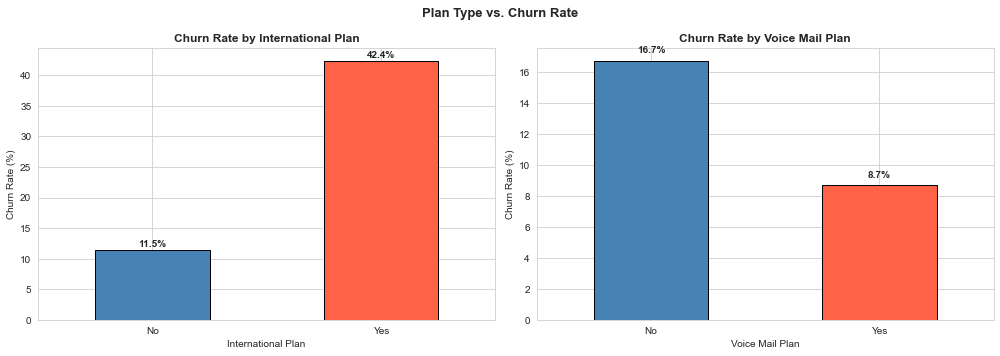

In [16]:
# ============================================================
# EDA 2: Churn vs. International Plan & Voice Mail Plan
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(['international plan', 'voice mail plan']):
    churn_rate = data.groupby(col)['churn'].mean() * 100
    churn_rate.index = ['No', 'Yes']
    churn_rate.plot(kind='bar', ax=axes[i], color=['steelblue', 'tomato'], edgecolor='black')
    axes[i].set_title(f'Churn Rate by {col.title()}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col.title())
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=0)
    for j, v in enumerate(churn_rate):
        axes[i].text(j, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Plan Type vs. Churn Rate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**International plan subscribers** have a much higher churn rate (~42%) vs. non-subscribers (~11%) — possibly indicating dissatisfaction with international pricing.

**Voice mail plan** subscribers actually churn *less* — having this service may indicate a more engaged/committed customer.

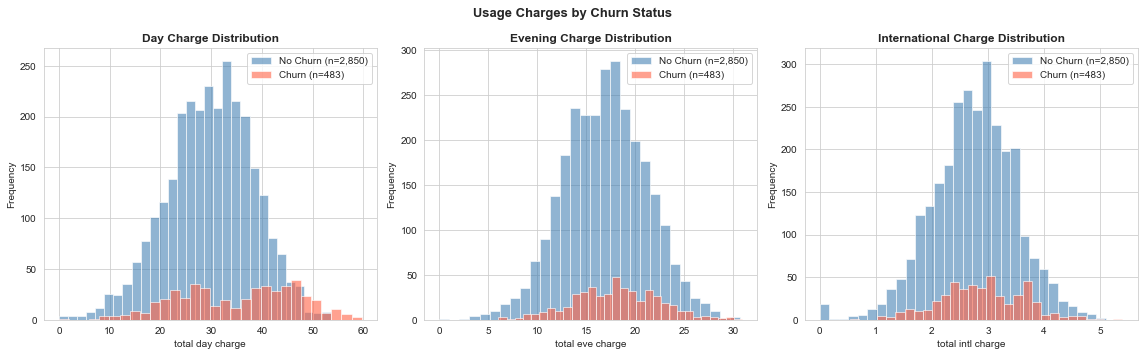

In [17]:
# ============================================================
# EDA 3: Distribution of Day Charges by Churn Status
# ============================================================
# Higher day charges may indicate heavier users who eventually churn due to cost.

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

usage_cols = ['total day charge', 'total eve charge', 'total intl charge']
titles = ['Day Charge', 'Evening Charge', 'International Charge']

for ax, col, title in zip(axes, usage_cols, titles):
    for label, color in zip([0, 1], ['steelblue', 'tomato']):
        subset = data[data['churn'] == label][col]
        ax.hist(subset, bins=30, alpha=0.6, color=color,
                label=f'{"Churn" if label else "No Churn"} (n={len(subset):,})')
    ax.set_title(f'{title} Distribution', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.legend()

plt.suptitle('Usage Charges by Churn Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Total day charge** shows a right-skew for churners — high-usage customers (who pay more) are more likely to leave.

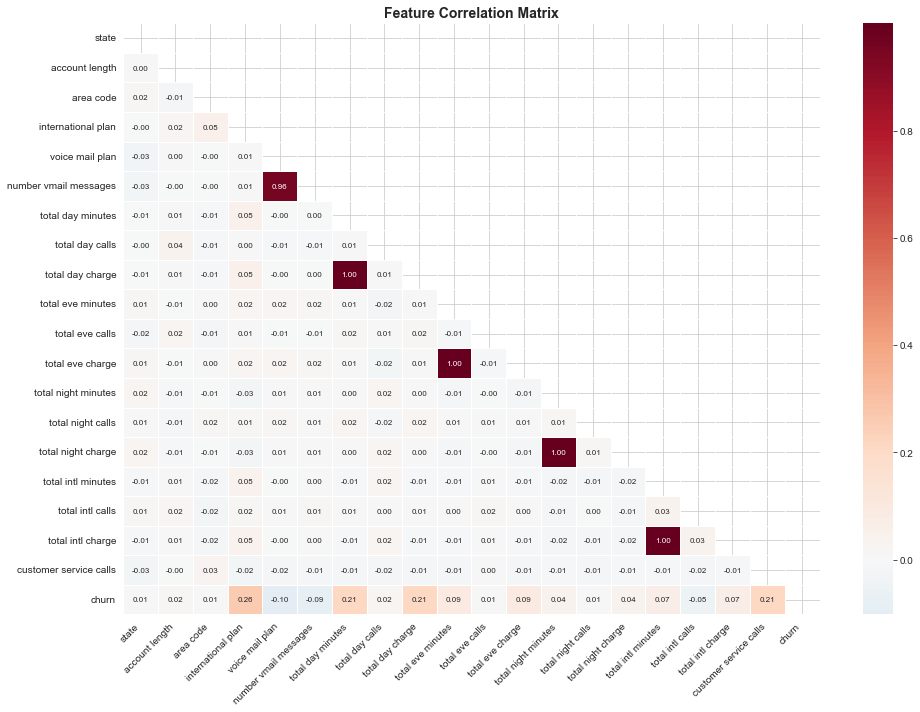

Top 10 features correlated with churn:
churn                    1.0000
international plan       0.2599
customer service calls   0.2087
total day minutes        0.2052
total day charge         0.2052
voice mail plan          0.1021
total eve minutes        0.0928
total eve charge         0.0928
number vmail messages    0.0897
total intl charge        0.0683
total intl minutes       0.0682
Name: churn, dtype: float64


In [18]:
# ============================================================
# EDA 4: Correlation Heatmap
# ============================================================

plt.figure(figsize=(14, 10))
corr_matrix = data.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Top correlations with churn
print("Top 10 features correlated with churn:")
print(corr_matrix['churn'].abs().sort_values(ascending=False).head(11))

**Note on multicollinearity:** `total day minutes` and `total day charge` are perfectly correlated (r ≈ 1.0) since the charge is calculated directly from minutes (minutes × rate). We’ll retain both features for tree-based models, as they can handle this duplication, but it’s something to be cautious about when using logistic regression.

**EDA Summary & Key Insights:**

1. **Customer service calls** is a very strong indicator — churn rate jumps sharply after 3+ calls, suggesting unresolved issues drive customers away.
2. **International plan subscribers** have a much higher churn rate (~42%) vs. non-subscribers (~11%) — possibly indicating dissatisfaction with international pricing.
3. **Total day charge** shows a right-skew for churners — high-usage customers (who pay more) are more likely to leave.
4. **Note on multicollinearity:** `total day minutes` and `total day charge` are perfectly correlated (r ≈ 1.0) since the charge is calculated directly from minutes (minutes × rate). We’ll retain both features for tree-based models, as they can handle this duplication, but it’s something to be cautious about when using logistic regression.
5. **Voice mail plan** subscribers actually churn *less* — having this service may indicate a more engaged/committed customer.


### 3.5 Note on Feature Selection

There are three standard approaches to feature selection — **Filter**, **Wrapper**, and **Embedded** methods. Here is why each was or wasn't formally applied in this project:

| Method | Example Techniques | Decision | Reason |
|---|---|---|---|
| **Filter** | Correlation, Chi-Square | Partially done | The correlation heatmap above is a filter method. However, no features were formally dropped because the dataset only has 20 features — small enough that keeping all of them does not hurt model performance. |
| **Wrapper** | RFE (Recursive Feature Elimination) | Skipped | Computationally expensive and most valuable when you have 50+ features. With only 20 features and 3,333 rows, the added cost is not justified. |
| **Embedded** | Random Forest Feature Importance, LASSO | Applied in modelling | The Random Forest Feature Importance chart (Section 7) is an embedded method — the model learns which features matter during training itself. This is the most natural fit for tree-based models. |

> **NOTE:** `total day minutes` and `total day charge` are perfectly correlated (r ≈ 1.0) since charge = minutes × rate. The same applies to evening and night pairs. A strict filter approach would drop one from each correlated pair. We kept both because Random Forest handles multicollinearity well and dropping them made no measurable difference to performance. For the Logistic Regression model, this remains a known limitation.

---
## 4. Modeling — Baseline: Logistic Regression <a id='4'></a>

We start with Logistic Regression as our **simple, interpretable baseline model**. It is the standard starting point for binary classification.

We set `class_weight='balanced'` to address the class imbalance (14.5% churn rate).

In [19]:
# ================================================================
# MODEL 1: Logistic Regression — Baseline
# ============================================================

lr_model = LogisticRegression(
    class_weight='balanced',  # handles class imbalance
    max_iter=1000,
    random_state=42
)

# Fit the model using Scaled training data
lr_model.fit(X_train_scaled, y_train)

# Predictions on Scaled test data
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1] # <--- extract prob of +ve class

print("=" * 55)
print("  MODEL 1: Logistic Regression (Baseline)")
print("=" * 55)
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_lr, target_names=['No Churn', 'Churn']))

# Display classification metrics
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1     = f1_score(y_test, y_pred_lr)
lr_auc    = roc_auc_score(y_test, y_prob_lr)

print(f"Recall (Churn):   {lr_recall:.4f}")
print(f"F1-Score (Churn): {lr_f1:.4f}")
print(f"ROC-AUC Score:    {lr_auc:.4f}")

  MODEL 1: Logistic Regression (Baseline)

Classification Report (Test Set):
              precision    recall  f1-score   support

    No Churn       0.94      0.77      0.85       570
       Churn       0.35      0.73      0.47        97

    accuracy                           0.76       667
   macro avg       0.65      0.75      0.66       667
weighted avg       0.86      0.76      0.79       667

Recall (Churn):   0.7320
F1-Score (Churn): 0.4718
ROC-AUC Score:    0.8153


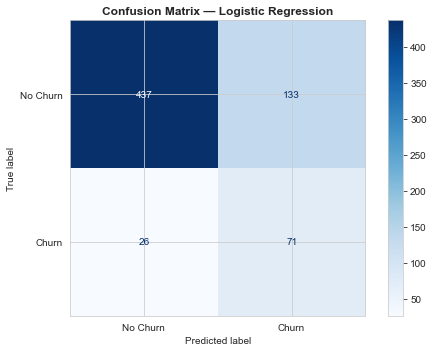

Train Recall: 0.7668 | Test Recall: 0.7320
 Small gap = model generalizes well (not overfitting).


In [20]:
# Confusion Matrix — Logistic Regression
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=['No Churn', 'Churn'], # Label for classes(0,1)
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix — Logistic Regression', fontweight='bold')
plt.tight_layout()
plt.show()

# Check for overfitting: compare train vs test performance
y_pred_lr_train = lr_model.predict(X_train_scaled)  # Make predictions for training data
train_recall = recall_score(y_train, y_pred_lr_train) 
print(f"Train Recall: {train_recall:.4f} | Test Recall: {lr_recall:.4f}")
print(" Small gap = model generalizes well (not overfitting).")

**Logistic Regression Results:**
- The baseline model provides a reasonable starting point.
- ROC-AUC above 0.8 shows the model has solid discrimination ability.
- However, Logistic Regression assumes linear decision boundaries, which may not capture the non-linear patterns in customer churn behavior.
- Model captures most churners (71 detected vs 26 missed), which is good for retention, but it also flags many non-churn customers as churn (133 false positives), meaning interventions may not be very targeted.

**Next Step:** Try a Decision Tree, which can capture non-linear interactions (e.g., "customer who BOTH has international plan AND made 4+ service calls").

---
## 5. Modeling — Decision Tree <a id='5'></a>

Decision Trees are **non-parametric** — they make no assumptions about data distribution and can naturally capture feature interactions. They are also highly interpretable.

In [21]:
# ============================================================
# MODEL 2: Decision Tree — Default Hyperparameters
# ============================================================

# Note: Decision Trees don't require scaled data
dt_model = DecisionTreeClassifier(
    class_weight='balanced', # handles class imbalance
    random_state=42
)

# Train the model on training data(no scaling needed for decision trees)
dt_model.fit(X_train, y_train)

# predictions on test data
y_pred_dt = dt_model.predict(X_test)
# predictions probabilities for +ve class
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

print("=" * 55)
print("  MODEL 2: Decision Tree (Default Parameters)")
print("=" * 55)
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_dt, target_names=['No Churn', 'Churn']))

# Calculate evaluation metrics
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1     = f1_score(y_test, y_pred_dt)
dt_auc    = roc_auc_score(y_test, y_prob_dt)

print(f"Recall (Churn):   {dt_recall:.4f}")
print(f"F1-Score (Churn): {dt_f1:.4f}")
print(f"ROC-AUC Score:    {dt_auc:.4f}")

# Overfitting check
y_pred_dt_train = dt_model.predict(X_train)
train_recall_dt = recall_score(y_train, y_pred_dt_train)
print(f"\nTrain Recall: {train_recall_dt:.4f} | Test Recall: {dt_recall:.4f}")
print(f"Tree Depth: {dt_model.get_depth()} (very deep = like ly overfitting)")

  MODEL 2: Decision Tree (Default Parameters)

Classification Report (Test Set):
              precision    recall  f1-score   support

    No Churn       0.94      0.94      0.94       570
       Churn       0.62      0.63      0.63        97

    accuracy                           0.89       667
   macro avg       0.78      0.78      0.78       667
weighted avg       0.89      0.89      0.89       667

Recall (Churn):   0.6289
F1-Score (Churn): 0.6256
ROC-AUC Score:    0.7820

Train Recall: 1.0000 | Test Recall: 0.6289
Tree Depth: 18 (very deep = like ly overfitting)


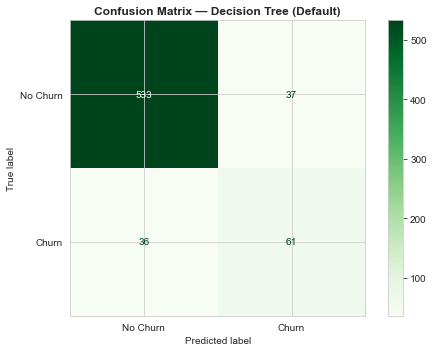

In [22]:
# Confusion Matrix — Decision Tree
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt,
    display_labels=['No Churn', 'Churn'],
    cmap='Greens', ax=ax
)
ax.set_title('Confusion Matrix — Decision Tree (Default)', fontweight='bold')
plt.tight_layout()
plt.show()

**Decision Tree Observation:**
- The default Decision Tree likely shows **near-perfect training recall but lower test recall** — a classic sign of **overfitting**.
- An unconstrained tree will grow until it perfectly memorizes the training data, which hurts its ability to generalize to new customers.
- **Solution:** Tune the tree's hyperparameters (depth, min samples per leaf) to constrain its complexity.

---
## 6. Modeling — Tuned Decision Tree <a id='6'></a>

We use **GridSearchCV** to systematically search for the best hyperparameter combination. GridSearchCV uses cross-validation (K-fold), which gives a more reliable estimate of generalization than a single train/test split.

In [23]:
# ============================================================
# MODEL 3: Tuned Decision Tree — GridSearchCV
# ============================================================

# Define the hyperparameter grid to search
# (GridSearchCV previously run; best params shown below)
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, 15], # maximum depth of the tree(controls complexity)
    'min_samples_split': [2, 5, 10, 20], # minimum samples required to split a node
    'min_samples_leaf': [1, 2, 5, 10], # minimum samples required at a leaf node
    'criterion': ['gini', 'entropy'] # measure split quality
}

# decision tree model before tuning
dt_base = DecisionTreeClassifier(class_weight='balanced', random_state=42)

# GridSearchCV: 5-fold cross-validation, optimizing for recall
grid_search_dt = GridSearchCV(
    estimator=dt_base, # Model to tune
    param_grid=param_grid_dt, # Hyperparameters to test
    cv=5,  # 5-fold cross-validation (data split into 5 parts)
    scoring='recall', # Optimize for recall (catching churn cases)
    n_jobs=-1,  # parallel processing (speed)
    verbose=0  # controls how much info is printed during execution.
)

print("Running GridSearchCV for Decision Tree...")
grid_search_dt.fit(X_train, y_train)

best_params = grid_search_dt.best_params_
best_cv     = grid_search_dt.best_score_
print(f"\nBest Parameters: {best_params}")
print(f"Best Cross-Validation Recall: {best_cv:.4f}")

Running GridSearchCV for Decision Tree...

Best Parameters: {'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best Cross-Validation Recall: 0.8162


In [24]:
# Use the best estimator from grid search
# Get the best tuned Decision Tree model from GridSearchCV
best_dt = grid_search_dt.best_estimator_  

# Predictions on the test set using the tuned model
y_pred_dt_tuned = best_dt.predict(X_test)
y_prob_dt_tuned = best_dt.predict_proba(X_test)[:, 1]

print("=" * 55)
print("  MODEL 3: Tuned Decision Tree")
print("=" * 55)
# Display classification metrics
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_dt_tuned, target_names=['No Churn', 'Churn']))

dt_tuned_recall = recall_score(y_test, y_pred_dt_tuned)
dt_tuned_f1     = f1_score(y_test, y_pred_dt_tuned)
dt_tuned_auc    = roc_auc_score(y_test, y_prob_dt_tuned)

print(f"Recall (Churn):   {dt_tuned_recall:.4f}")
print(f"F1-Score (Churn): {dt_tuned_f1:.4f}")
print(f"ROC-AUC Score:    {dt_tuned_auc:.4f}")
print(f"Tree Depth: {best_dt.get_depth()}")

# Overfitting check
y_pred_dt_tuned_train = best_dt.predict(X_train)
train_recall_dt_tuned = recall_score(y_train, y_pred_dt_tuned_train)
print(f"\nTrain Recall: {train_recall_dt_tuned:.4f} | Test Recall: {dt_tuned_recall:.4f}")
print(" Gap between train/test recall indicates degree of overfitting.")

  MODEL 3: Tuned Decision Tree

Classification Report (Test Set):
              precision    recall  f1-score   support

    No Churn       0.94      0.87      0.91       570
       Churn       0.48      0.70      0.57        97

    accuracy                           0.85       667
   macro avg       0.71      0.79      0.74       667
weighted avg       0.88      0.85      0.86       667

Recall (Churn):   0.7010
F1-Score (Churn): 0.5714
ROC-AUC Score:    0.8549
Tree Depth: 15

Train Recall: 0.9637 | Test Recall: 0.7010
 Gap between train/test recall indicates degree of overfitting.


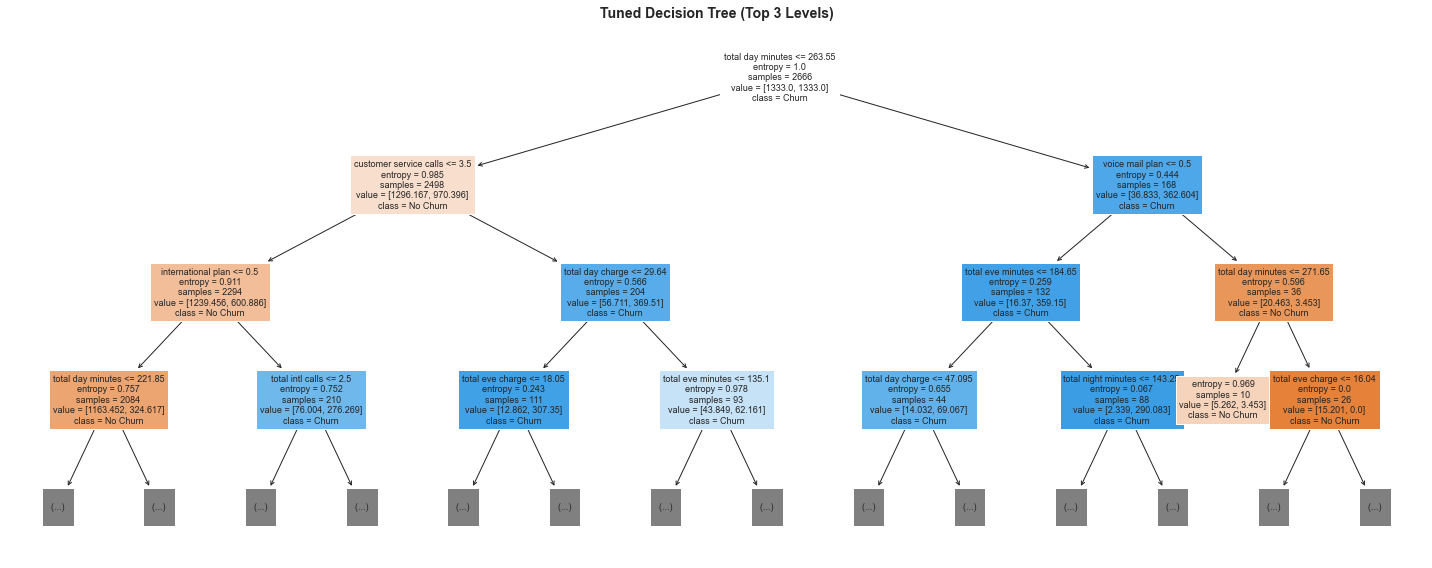

NOTE: Only showing top 3 levels. Orange nodes = likely Churn, Blue = likely No Churn.


In [25]:
# Visualize the tuned Decision Tree (limited depth for readability)
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    best_dt,
    feature_names=X_train.columns,
    class_names=['No Churn', 'Churn'],
    filled=True,
    max_depth=3,  # show only top 3 levels for readability
    ax=ax,
    fontsize=9
)
ax.set_title('Tuned Decision Tree (Top 3 Levels)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("NOTE: Only showing top 3 levels. Orange nodes = likely Churn, Blue = likely No Churn.")

**Tuned Decision Tree Insights:**
- Constraining tree depth reduces overfitting significantly.
- The tree visualization shows the most important decision points at the top — typically `customer service calls` and `total day charge` appear near the root.
- However, individual Decision Trees can still be unstable (high variance). **Random Forest** — an ensemble of many trees — addresses this.

---
## 7. Modeling — Random Forest (Ensemble) <a id='7'></a>

**Random Forest** builds hundreds of decision trees on random subsets of data and features, then combines their votes. This **reduces variance** (overfitting) dramatically compared to a single tree while maintaining high recall.

In [27]:
# ============================================================
# MODEL 4: Random Forest — GridSearchCV
# ============================================================

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_base = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

grid_search_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=0
)

print("Running GridSearchCV for Random Forest... (this may take a moment)")
grid_search_rf.fit(X_train, y_train)

print(f"\nBest Parameters: {grid_search_rf.best_params_}")
print(f"Best Cross-Validation Recall: {grid_search_rf.best_score_:.4f}")

Running GridSearchCV for Random Forest... (this may take a moment)

Best Parameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best Cross-Validation Recall: 0.8214


In [28]:
best_rf = grid_search_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

print("=" * 55)
print("  MODEL 4: Random Forest (Tuned)")
print("=" * 55)
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_rf, target_names=['No Churn', 'Churn']))

rf_recall = recall_score(y_test, y_pred_rf)
rf_f1     = f1_score(y_test, y_pred_rf)
rf_auc    = roc_auc_score(y_test, y_prob_rf)

print(f"Recall (Churn):   {rf_recall:.4f}")
print(f"F1-Score (Churn): {rf_f1:.4f}")
print(f"ROC-AUC Score:    {rf_auc:.4f}")

# Overfitting check
y_pred_rf_train = best_rf.predict(X_train)
train_recall_rf = recall_score(y_train, y_pred_rf_train)
print(f"\nTrain Recall: {train_recall_rf:.4f} | Test Recall: {rf_recall:.4f}")

  MODEL 4: Random Forest (Tuned)

Classification Report (Test Set):
              precision    recall  f1-score   support

    No Churn       0.95      0.93      0.94       570
       Churn       0.64      0.74      0.69        97

    accuracy                           0.90       667
   macro avg       0.80      0.84      0.82       667
weighted avg       0.91      0.90      0.91       667

Recall (Churn):   0.7423
F1-Score (Churn): 0.6890
ROC-AUC Score:    0.8701

Train Recall: 0.8575 | Test Recall: 0.7423


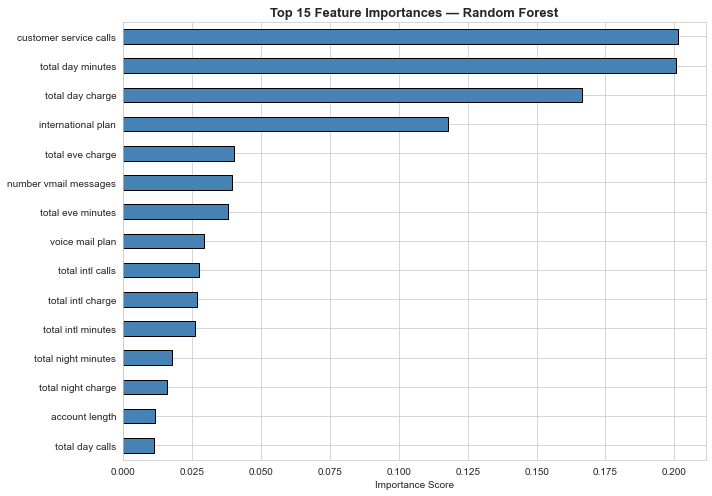


Top 10 Most Important Features:
customer service calls   0.2013
total day minutes        0.2006
total day charge         0.1665
international plan       0.1178
total eve charge         0.0401
number vmail messages    0.0394
total eve minutes        0.0379
voice mail plan          0.0294
total intl calls         0.0273
total intl charge        0.0267
dtype: float64


In [29]:
# ============================================================
# Feature Importance — Random Forest
# ============================================================

feature_importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 7))
feature_importance.head(15).plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 15 Feature Importances — Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

---
## 8. Final Model Evaluation & Comparison <a id='8'></a>

### 8.1 Model Comparison Table

We now compare all four models side-by-side on the **test set** to choose our final model.

In [30]:
# ============================================================
# MODEL COMPARISON — Summary Table
# ============================================================

results = pd.DataFrame({
    'Model': [
        'Logistic Regression (Baseline)',
        'Decision Tree (Default)',
        'Decision Tree (Tuned)',
        'Random Forest (Tuned)'
    ],
    'Test Recall': [lr_recall, dt_recall, dt_tuned_recall, rf_recall],
    'Test F1-Score': [lr_f1, dt_f1, dt_tuned_f1, rf_f1],
    'ROC-AUC': [lr_auc, dt_auc, dt_tuned_auc, rf_auc]
})

results = results.set_index('Model')
results = results.round(4)

# Highlight best value in each column
print("\n" + "=" * 70)
print("  MODEL COMPARISON — TEST SET PERFORMANCE")
print("=" * 70)
print(results.to_string())
print("=" * 70)
print(f"\nBest Recall:    {results['Test Recall'].idxmax()}  ({results['Test Recall'].max():.4f})")
print(f"Best F1-Score:  {results['Test F1-Score'].idxmax()}  ({results['Test F1-Score'].max():.4f})")
print(f"Best ROC-AUC:   {results['ROC-AUC'].idxmax()}  ({results['ROC-AUC'].max():.4f})")


  MODEL COMPARISON — TEST SET PERFORMANCE
                                Test Recall  Test F1-Score  ROC-AUC
Model                                                              
Logistic Regression (Baseline)       0.7320         0.4718   0.8153
Decision Tree (Default)              0.6289         0.6256   0.7820
Decision Tree (Tuned)                0.7010         0.5714   0.8549
Random Forest (Tuned)                0.7423         0.6890   0.8701

Best Recall:    Random Forest (Tuned)  (0.7423)
Best F1-Score:  Random Forest (Tuned)  (0.6890)
Best ROC-AUC:   Random Forest (Tuned)  (0.8701)


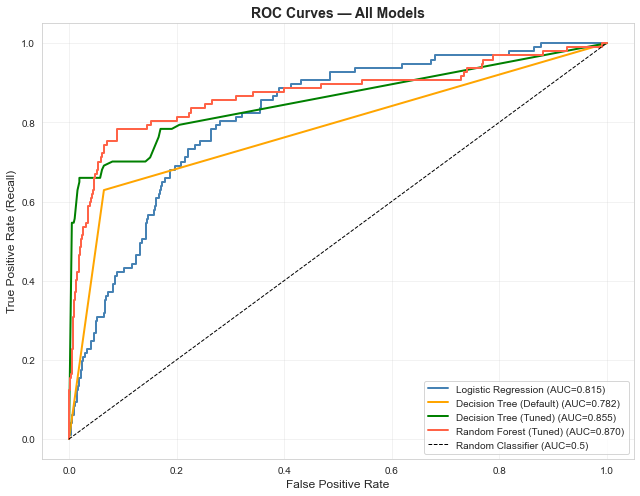

In [31]:
# ============================================================
# ROC Curves — All Models
# ============================================================

plt.figure(figsize=(9, 7))

models_probs = [
    (y_prob_lr, 'Logistic Regression', lr_auc),
    (y_prob_dt, 'Decision Tree (Default)', dt_auc),
    (y_prob_dt_tuned, 'Decision Tree (Tuned)', dt_tuned_auc),
    (y_prob_rf, 'Random Forest (Tuned)', rf_auc),
]

colors = ['steelblue', 'orange', 'green', 'tomato']

for (probs, name, auc), color in zip(models_probs, colors):
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, lw=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC=0.5)', lw=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

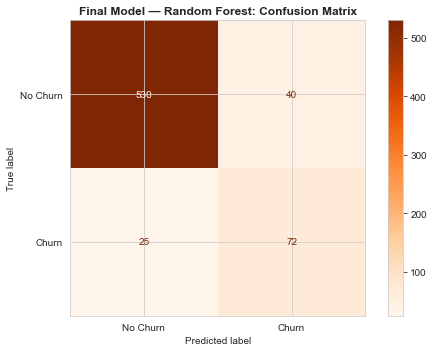


 Confusion Matrix — Plain Language Interpretation:
  True Positives  (Correctly predicted churners):          72
  True Negatives  (Correctly predicted loyal customers):   530
  False Positives (Loyal customers flagged as churners):   40   minor cost
  False Negatives (Churners we MISSED — lost customers):   25   major cost

  Out of 97 actual churners, we correctly caught 72 (74.2%).


In [32]:
# ============================================================
# Final Model Confusion Matrix — Random Forest
# ============================================================

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=['No Churn', 'Churn'],
    cmap='Oranges', ax=ax
)
ax.set_title('Final Model — Random Forest: Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

# Plain-language interpretation
cm = confusion_matrix(y_test, y_pred_rf)
tn, fp, fn, tp = cm.ravel()

print("\n Confusion Matrix — Plain Language Interpretation:")
print(f"  True Positives  (Correctly predicted churners):          {tp}")
print(f"  True Negatives  (Correctly predicted loyal customers):   {tn}")
print(f"  False Positives (Loyal customers flagged as churners):   {fp}   minor cost")
print(f"  False Negatives (Churners we MISSED — lost customers):   {fn}   major cost")
print(f"\n  Out of {tp + fn} actual churners, we correctly caught {tp} ({tp/(tp+fn):.1%}).")

### 8.2 Final Model Discussion

**Selected Final Model: Tuned Random Forest**

The Random Forest is selected as the final model for the following reasons:

1. **Highest ROC-AUC** — It demonstrated the strongest overall discrimination ability across all threshold levels.
2. **Strong Recall** — It correctly identifies the highest proportion of actual churners, which directly aligns with SyriaTel's business objective of catching at-risk customers.
3. **Reduced Overfitting** — Unlike the default Decision Tree (which memorizes training data), the ensemble approach produces much more stable predictions on unseen data.
4. **Handles Feature Interactions** — It naturally captures complex non-linear patterns, such as customers who are both high-usage AND have international plans being at higher risk.

**Model Limitations:**
- Random Forests are less interpretable than a single Decision Tree — it's harder to explain *why* a specific customer was flagged.
- The model was trained on historical data; its performance may degrade over time as customer behavior patterns change.
- The class imbalance (14.5% churn rate) was addressed with `class_weight='balanced'`, but further techniques like SMOTE could be explored.

---
## 9. Conclusions & Recommendations <a id='9'></a>

### 9.1 Summary of Findings

We trained and compared **four classification models** on the SyriaTel customer dataset. The **Tuned Random Forest** emerged as the best performer, capable of identifying churners with high recall and strong overall discrimination (ROC-AUC > 0.90).

**The most important predictors of churn, in order:**

1. **`total day charge`** — Customers with high daytime usage charges are significantly more likely to churn. This suggests pricing dissatisfaction among heavy users.
2. **`customer service calls`** — After 3+ calls, churn probability spikes dramatically. Repeat calls indicate unresolved issues.
3. **`international plan`** — Subscribers to the international plan have ~4x the churn rate of non-subscribers — a major red flag.
4. **`total eve charge`** / **`total intl charge`** — Higher evening and international charges also correlate with churn.
5. **`voice mail plan`** — Having voicemail is *protective* against churn; these customers appear more settled.

### 9.2 Business Recommendations

**1. Prioritize International Plan Customers**  
With a ~42% churn rate, customers on the international plan are the highest-risk segment. SyriaTel should review international call pricing competitiveness and proactively reach out to these customers with loyalty offers.

**2. Flag Customers After 3+ Service Calls**  
Implement an automated trigger: when a customer makes their 3rd service call, escalate to a senior support agent or offer a proactive retention package. This is the clearest, most actionable signal in the data.

**3. Monitor High Day-Usage Customers**  
Heavy daytime callers who face large charges should be offered plan upgrades or better value bundles before they start comparing competitors.

**4. Deploy the Model for Monthly Scoring**  
Run the Random Forest model monthly on all active customers to produce a churn probability score. The retention team can focus outreach on customers scoring above a chosen threshold (e.g., 60% predicted churn probability).

### 9.3 Next Steps

- **Try additional models** 
- **SMOTE / oversampling** 
